# Task 1
Побудуйте дерево рішень і перевірте, наскільки добре воно передбачає ціни на житло.
* Завантажте датасет California Housing.
* Використовуйте ознаки MedInc, HouseAge, AveRooms, AveBedrms.
* Розділіть дані на train/test (80/20, random_state=42).
* Навчіть модель DecisionTreeRegressor(max_depth=4, random_state=42).
* Обчисліть R² на тестовій вибірці.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown as md
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

In [3]:
california = fetch_california_housing(as_frame=True)
X = california.frame[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']]
y = california.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeRegressor(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

r2_dt = r2_score(y_test, dt.predict(X_test))

display(md("|Model|Test R²|\n|-|-|\n|DecisionTreeRegressor|%f|\n" % r2_dt))

|Model|Test R²|
|-|-|
|DecisionTreeRegressor|0.507482|


# Task 2
Порівняйте якість передбачень одного дерева й ансамблю дерев.
* Використовуйте ті самі дані й ознаки.
* Навчіть:
    - DecisionTreeRegressor(max_depth=4, random_state=42);
    - RandomForestRegressor(n_estimators=100, random_state=42).
* Обчисліть R² на тестовій вибірці.
* Оформіть результат у таблиці:

In [5]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

r2_rf = r2_score(y_test, rf.predict(X_test))

md("|Model|Test R²|\n|-|-|\n|DecisionTreeRegressor|%f|\n|RandomForestRegressor|%f|\n" % (
    r2_dt, 
    r2_rf
))

|Model|Test R²|
|-|-|
|DecisionTreeRegressor|0.507482|
|RandomForestRegressor|0.588715|


# Task 3
Побудуйте модель градієнтного бустингу і порівняйте її з результатами випадкового лісу:
* Використовуйте ті самі дані (California Housing).
* Навчіть модель XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42).
* Обчисліть R² на тестовій вибірці.
* Порівняйте результат із Random Forest із Завдання 2.

In [6]:
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)

r2_xgb = r2_score(y_test, xgb.predict(X_test))

md("|Model|Test R²|\n|-|-|\n|RandomForestRegressor|%f|\n|XGBRegressor|%f|\n" % (
    r2_rf, 
    r2_xgb
))

|Model|Test R²|
|-|-|
|RandomForestRegressor|0.588715|
|XGBRegressor|0.598551|


# Task 4
* Спробуйте розв'язати задачу класифікації на основі цін на житло:
* Використовуйте California Housing.
* Перетворіть цільову змінну на бінарну:
    - клас 1, якщо ціна вища за медіану,
    - клас 0, якщо ціна нижча або дорівнює медіані.
* Для цього обчисліть np.median(y) і створіть y_class = (y > median_price).astype(int).
* Розділіть дані на train/test (80/20, random_state=42).
* Навчіть модель LogisticRegression(max_iter=1000).
* Побудуйте confusion matrix і виведіть Accuracy, Precision, Recall, F1.

In [16]:
X_all = california.data
y_all = california.target

y_class = (y_all > np.median(y_all)).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_all,
    y_class,
    test_size=0.2,
    random_state=42
)

from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_c), columns=X_train_c.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_c), columns=X_test_c.columns)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train_c)

y_pred_c = log_reg.predict(X_test_scaled)

acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

md("|Metric|Value|\n|-|-|\n|Accuracy|%f|\n|Precision|%f|\n|Recall|%f|\n|F1 Score|%f|\n" % (
    acc, 
    prec, 
    rec, 
    f1
))

|Metric|Value|
|-|-|
|Accuracy|0.826066|
|Precision|0.825281|
|Recall|0.824476|
|F1 Score|0.824878|


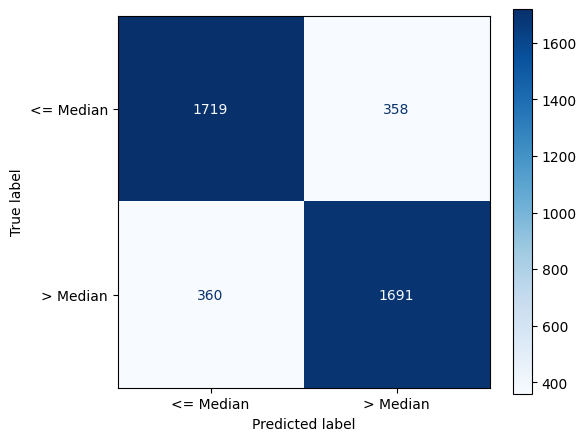

In [17]:
cm = confusion_matrix(y_test_c, y_pred_c)
_, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<= Median', '> Median'])
disp.plot(cmap='Blues', ax=ax)
plt.show()